# Bài 2: Xác suất thống kê cho AI

## Tải dữ liệu Iris

In [35]:
import seaborn as sns # trực quan hóa dữ liệu
import pandas as pd # xử lý dữ liệu dạng bảng
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# tải tệp dữ liệu
df = sns.load_dataset("iris")

## Tổng quan tệp dữ liệu Iris

Iris gồm 150 mẫu và 3 loài hoa Diên vĩ (tương ứng mỗi loài 50 mẫu): Iris Setosa, Iris Versicolor, Iris Virginica.

Gồm 5 thuộc tính (4 thuộc tính dạng số thực dùng cho phân tích và 1 thuộc tính là nhãn phân loại)
- Chiều dài lá đài (Sepal Length)
- Chiều rộng lá đài (Sepal Width)
- Chiều dài cánh hoa (Petal Length)
- Chiều rộng cánh hoa (Petal Width)
- Loài (Species)

## Phần 1: Thống kê mô tả và đặc trưng

## 1. Đọc dữ liệu, hiển thị 5 dòng đầu; cho biết số dòng, số cột và kiểu dữ liệu của từng cột.

In [36]:
# Tiền xử lý dữ liệu
print(df.head(5))
print("Shape:", df.shape)
print(df.dtypes) # dữ liệu của từng cột

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object


## 2. Với mỗi biến số, tính: mean, median, mode, var, std, min, max, Q1, Q3 và IQR.

In [37]:
# chọn các cột số
cols = df.select_dtypes(include=np.number).columns

# tính mean (trung bình)
print("Mean:")
print(df[cols].mean())

# tính median (trung vị)
print("Median:")
print(df[cols].median())

# tính mode (giá trị xuất hiện nhiều nhất)
print("Mode:")
print(df[cols].mode().iloc[0])

# tính variance (phương sai)
print("Var:")
print(df[cols].var())

# tính std (độ lệch chuẩn)
print("Std:")
print(df[cols].std())

# tính min (giá trị nhỏ nhất)
print("Min:")
print(df[cols].min())

# tính max (giá trị lớn nhất)
print("Max:")
print(df[cols].max())

# tính Q1 (tứ phân vị thứ nhất)
Q1 = df[cols].quantile(0.25)
print("Q1:", Q1)

# tính Q3 (tứ phân vị thứ ba)
Q3 = df[cols].quantile(0.75)
print("Q3:", Q3)

# tính IQR (khoảng tứ phân vị)
IQR = Q3 - Q1
print("IQR:", IQR)

Mean:
sepal_length    5.843333
sepal_width     3.057333
petal_length    3.758000
petal_width     1.199333
dtype: float64
Median:
sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal_width     1.30
dtype: float64
Mode:
sepal_length    5.0
sepal_width     3.0
petal_length    1.4
petal_width     0.2
Name: 0, dtype: float64
Var:
sepal_length    0.685694
sepal_width     0.189979
petal_length    3.116278
petal_width     0.581006
dtype: float64
Std:
sepal_length    0.828066
sepal_width     0.435866
petal_length    1.765298
petal_width     0.762238
dtype: float64
Min:
sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64
Max:
sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64
Q1: sepal_length    5.1
sepal_width     2.8
petal_length    1.6
petal_width     0.3
Name: 0.25, dtype: float64
Q3: sepal_length    6.4
sepal_width     3.3
petal_length    5.1
petal_width     1.8
Name: 0.75, dtype: float64


# Luận giải

Do có thể có nhiều mode nên Pandas có nhiệm vụ trả về số dòng tương ứng và .iloc[0] dùng để lấy dòng đầu tiên.

IQR giúp:
- Đo lường độ phân tán: cho biết độ biến động của phần trung tâm của tệp. IQR càng lớn thì dữ liệu càng phân tán.
- Loại bỏ ngoại lệ: phát hiện và loại bỏ các giá trị bất thường nằm quá xa phần lớn dữ liệu (nhỏ hơn Q1 - 1.5*(IQR) hoặc lớn hơn Q3 + 1.5*(IQR)).

## 3. Theo từng nhóm (loài species): dùng groupy tính mean và std của từng biến. Nhận xét nhóm nào khác biệt rõ nhất.

In [38]:
group_mean = df.groupby("species").mean(numeric_only=True)
group_std = df.groupby('species').std(numeric_only=True)

print("Mean theo species:", group_mean)
print("Std theo species:", group_std)

Mean theo species:             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026
Std theo species:             sepal_length  sepal_width  petal_length  petal_width
species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


## So sánh để rút ra nhận xét

Dữ liệu được nhóm sau đó tính. Việc phân nhóm giúp so sánh đặc trưng của mỗi loài.

Khi so sánh giá trị trung bình (mean) của các thuộc tính, Setosa khác biệt hơn hẳn.
- Chiều dài và độ rộng cánh hoa Setosa nhỏ hơn nhiều, còn Versicolor và Virginica có giá trị khá gần nhau về đài hoa.
- Virginica có chiều dài và chiều rộng lớn nhất.
- Versicolor nằm giữa Virginica và Setosa.

## Phần 2: Phân phối xác suất

## 1. Vẽ histogram + KDE cho từng biến số. Nhận xét hình dạng phân phối: lệch trái /phải, gần phân phối chuẩn, hay nhiều đỉnh?

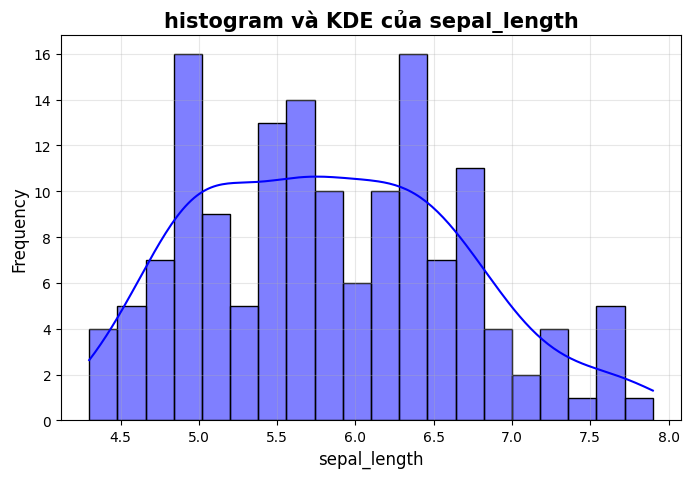

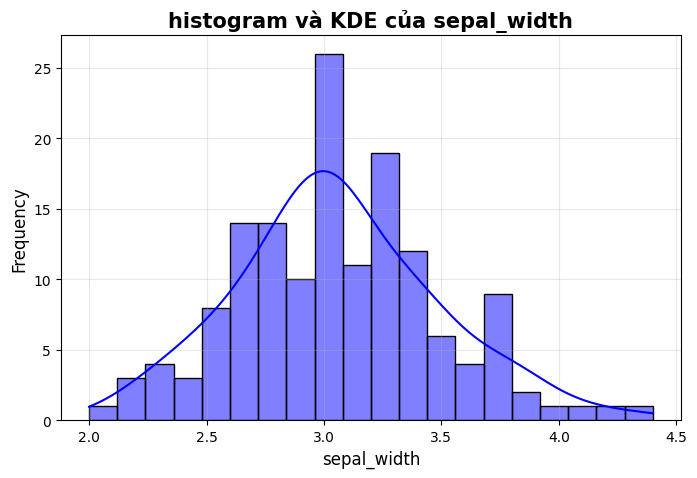

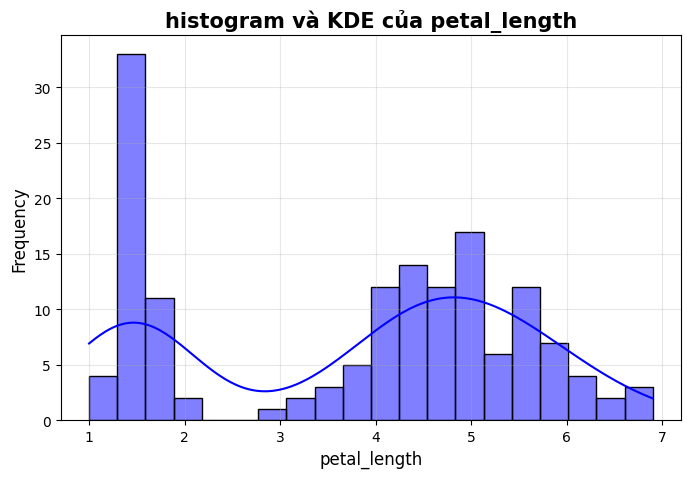

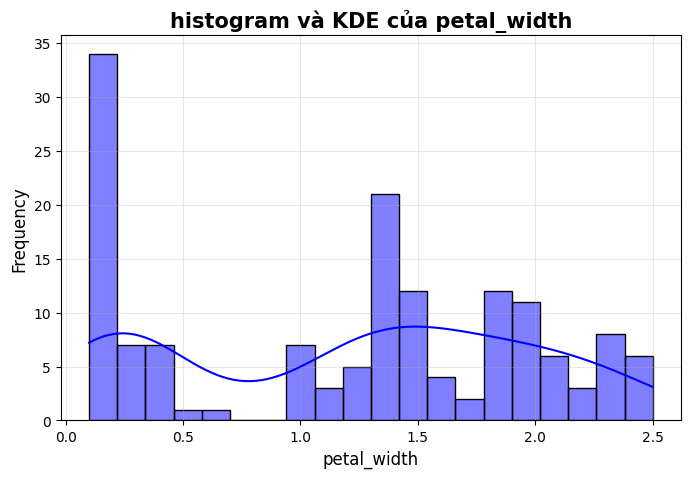

In [39]:
for col in cols:
    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=col,
        kde=True, # hiển thị thêm đường KDE giúp quan sát xu hướng phân phối dễ hơn
        bins=20, # chia dữ liệu thành 20 khoảng
        color="blue",
        edgecolor="black",
        linewidth=1
    )

    plt.title(f"histogram và KDE của {col}", fontsize=15, fontweight="bold")
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.grid(alpha=0.3)
    
    plt.show()

## Lý giải Histogram và KDE

Histogram: tần suất xuất hiện của các giá trị trong từng khoảng dữ liệu.
KDE: quan sát hình dạng phân phối một cách mượt mà hơn.

Biểu đồ cho thấy:
- Chiều dài và chiều rộng cánh hoa xuất hiện nhiều đỉnh phân phối => dữ liệu chia thành nhiều điểm khác nhau.
- Chiều dài lá đài có phân phối rộng.
- Chiều rộng lá đài tập trung quanh giá trị trung tâm.

Tóm lại, vẽ histogram kết hợp KDE để quan sát hình dạng phân phối của dữ liệu, mức độ tập trung và xu hướng phân tán của từng biến.

## 2. Vẽ boxplot từng biến theo nhóm (species) để so sánh phân phối giữa các loài.

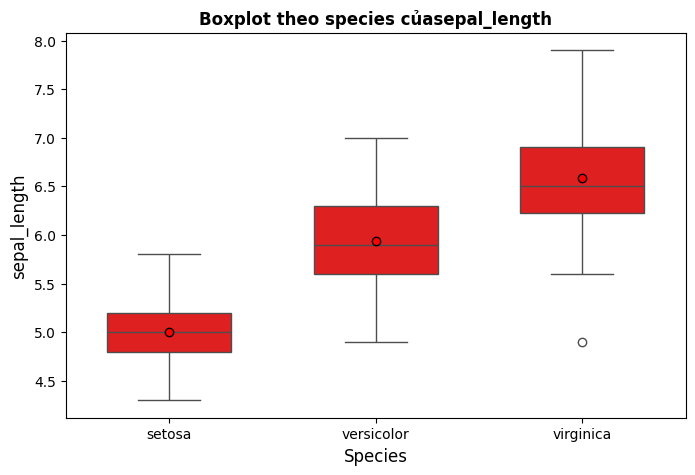

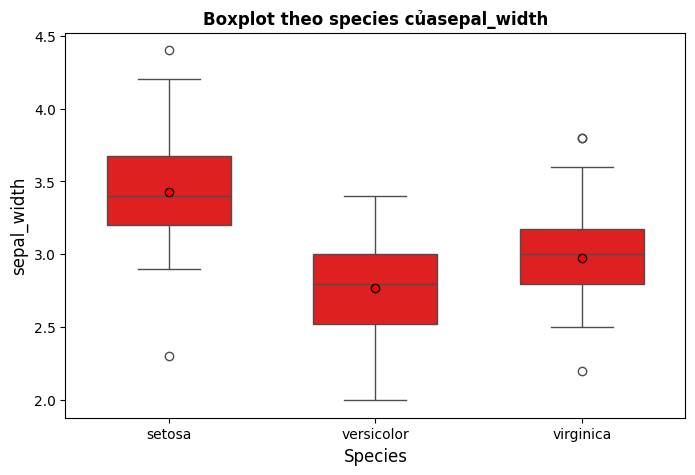

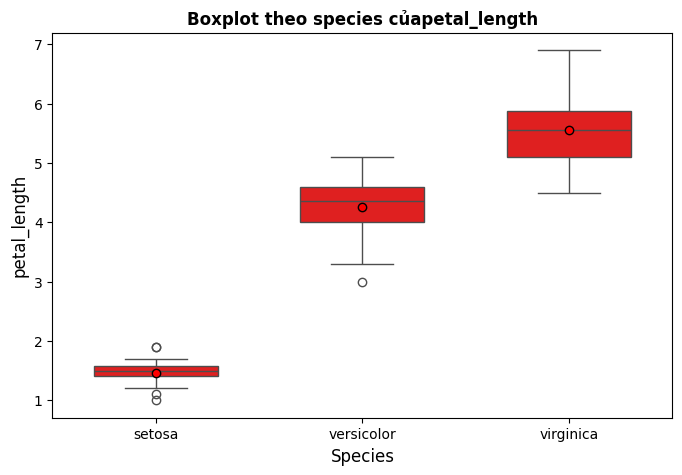

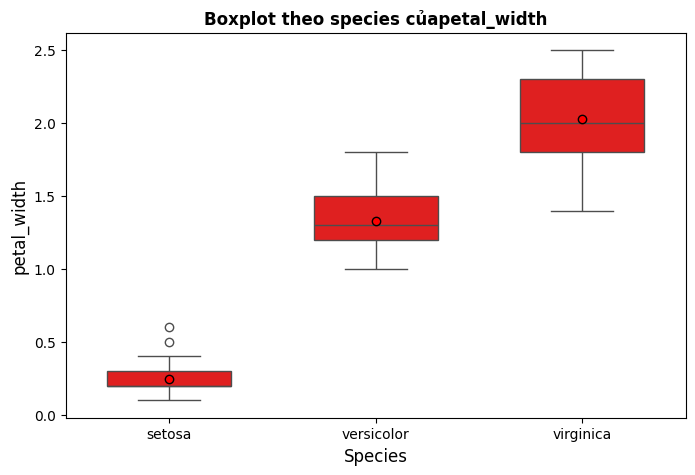

In [40]:
for col in cols: # lặp qua từng biến số trong danh sách cols
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="species",
        y=col,
        color="red",
        width=0.6,
        showmeans=True, # hiển thị giá trị trung bình trên boxplot
        meanprops={
            "marker": "o",
            "markerfacecolor": "red",
            "markeredgecolor": "black",
            "markersize": 6
        }
    )

    plt.title(f"Boxplot theo species của{col}", fontsize=12, fontweight="bold")
    plt.xlabel("Species", fontsize=12)
    plt.ylabel(col, fontsize=12)
    
    plt.show()

## Lý giải boxplot

Boxplot được sử dụng để tóm tắt phân phối dữ liệu và so sánh sự khác biệt giữa các nhóm species, đồng thời phát hiện các giá trị ngoại lệ nếu có.

## 3. Mô phỏng: chọn một biến, sinh mẫu từ phân phối Normal có cùng mean và std bằng np.random.normal; vẽ chồng histogram dữ liệu thực tế với đường PDF lý thuyết. 

Mean = 5.8433
Std = 0.8281


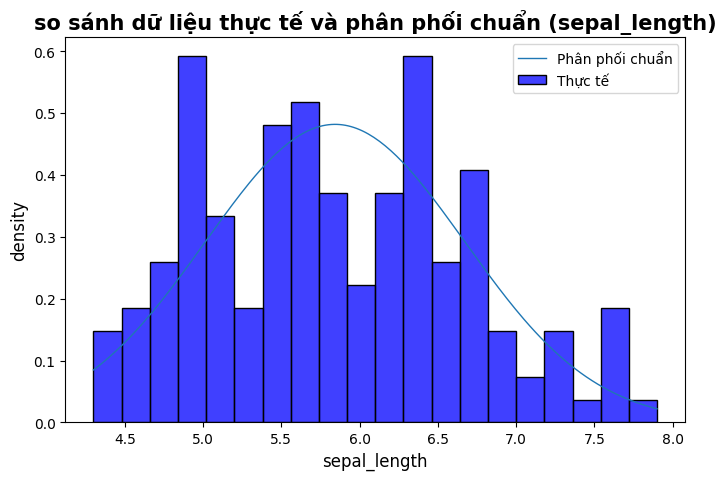

In [41]:
# chọn biến
col = "sepal_length"

# sinh mẫu từ phân phối Normal có cùng mean và std
mean = df[col].mean()
std = df[col].std()

print(f"Mean = {mean:.4f}") # lấy 4 chữ số thập phân
print(f"Std = {std:.4f}")

# sinh ngẫu nhiên 1000 giá trị từ phân phối chuẩn
bg_data = np.random.normal(
    loc=mean,
    scale=std,
    size=1000
)

# vẽ histogram chồng
plt.figure(figsize=(8,5))

sns.histplot(    
    df[col],
    bins=20,
    color="blue",
    edgecolor="black",
    linewidth=1,
    stat="density",
    label="Thực tế"
    )

x = np.linspace(
    df[col].min(),
    df[col].max(),
    200
) # tạo 200 điểm đều nhau từ GTNN đến GTLN

# tính PDF (mật độ xác suất)
pdf = norm.pdf(x, mean, std)

# vẽ PDF
plt.plot(
    x,
    pdf,
    label="Phân phối chuẩn",
    linewidth=1
)

plt.title(f"so sánh dữ liệu thực tế và phân phối chuẩn ({col})", fontsize=15, fontweight="bold")
plt.xlabel(col, fontsize=12)
plt.ylabel("density", fontsize=12)
plt.legend()

plt.show()

## Nhận xét mức độ khớp.

Mức độ khớp: không khớp hoàn toàn.

Theo thứ tự: 
Tính mean và std của dữ liệu thực tế.
=> Tạo đường cong phân phối chuẩn có cùng mean và std.
=> Vẽ histogram từ dữ liệu thực tế.
=> Chồng đường cong chuẩn lên histogram.
=> Quan sát.

Kết quả: histogram xuất hiện nhiều điểm lệch mạnh, không giống đường cong đã tạo nên không khớp hoàn toàn so với phân phối chuẩn.

## Phần 3: Phân tích đa biến và tương quan

## 1. Tính ma trận hiệp phương sai (covariance) và tương quan (correlation) giữa các biến số.

In [42]:
cov_matrix = df[cols].cov()
corr_matrix = df[cols].corr()

print("Ma trận hiệp phương sai giữa các biến:")
print(cov_matrix)

print("Hệ số tương quan giữa các biến:")
print(corr_matrix)

Ma trận hiệp phương sai giữa các biến:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006
Hệ số tương quan giữa các biến:
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


## Lý giải phân tích 

Cov:
Cov > 0: hai biến tăng cùng chiều.
Cov < 0: một tăng một giảm.
Cov gần bằng 0: ít hoặc không có mối quan hệ tuyến tính.

Corr:
r gần bằng 1: tương quan dương mạnh.
r gần bằng -1: tương quan âm mạnh.
r gần bằng 0: tương quan tuyến tính yếu hoặc không có.

Đánh giá mối quan hệ giữa các biến số trong bộ dữ liệu. 

## 2. Vẽ heatmap tương quan; nhận xét cặp biến tương quan mạnh nhất. Có dấu hiệu đa cộng tuyến không?

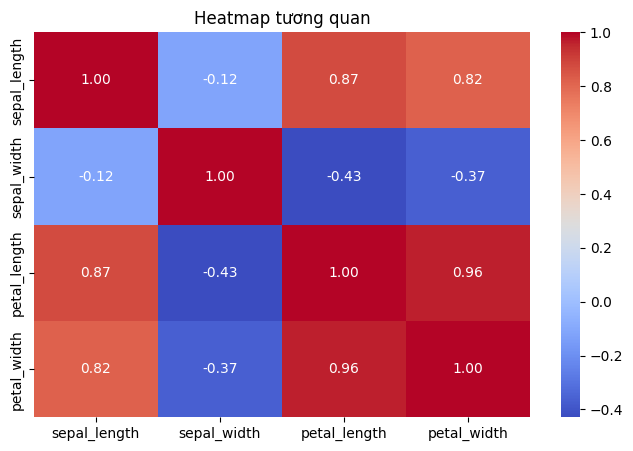

In [43]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Heatmap tương quan")
plt.show()

## Nhận xét: 

Heatmap cho thấy petal_length và petal_width là cặp biến có tương quan mạnh nhất và vượt quá ngưỡng cho phép nên có dấu hiệu đa cộng tuyến mạnh. 
Ngoài ra, sepal_length cũng có tương quan khá mạnh với petal_length và petal_width nhưng sepal_width lại có tương quan yếu hơn so với các biến còn lại.

## 3. Vẽ pairplot (hoặc scatter theo cặp), tô màu theo species; nhận xét quan hệ giữa các biến.

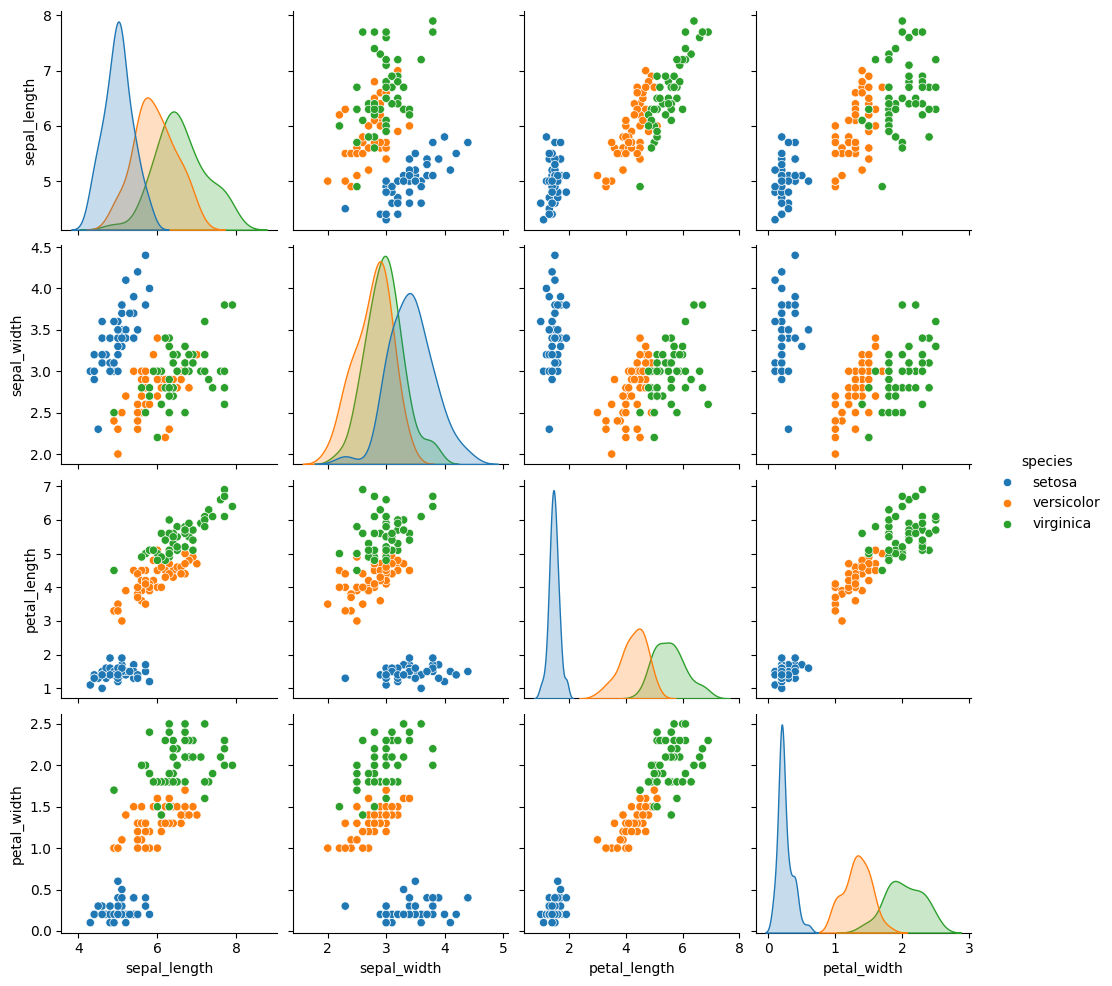

In [44]:
sns.pairplot(
    df,
    hue="species"
)

plt.show()

## Cách đọc Pairplot:

Đường chéo (diagonal):
- Hiển thị histogram hoặc KDE của từng biến.
- Cho biết phân phối của từng đặc trưng theo loài.

Các ô ngoài đường chéo:
- Là scatter plot giữa hai biến.
- Mỗi màu tương ứng mỗi loài hoa.

## Nhận xét quan hệ giữa các biến:

Các cụm của loài Setosa tập trung riêng (đặc biệt: petal_length và petal_width) => dễ nhận diện nhất.
Các điểm của petal_length và petal_width tạo thành xu hướng gần đường thẳng đi lên => tương quan mạnh.
Loài Versicolor và loài Virginica có vùng dữ liệu giao nhau => cần kết hợp nhiều đặc trưng khác để phân loại rõ rệt.

## Phần 4: Xác suất và Định lý Bayes

## Bài toán chẩn đoán: Một bệnh có tỉ lệ mắc trong dân số là P(B) = 0.01. Một xét nghiệm có:
+ Độ nhạy (true positive): P(+/B) = 0.99.
+ Dương tính giả (false positive): P(+/-B) =0.05.

## 1. Viết code tính xác suất hậu nghiệm P(B/+) bằng định lý Bayes và in kết quả.

In [45]:
P_B = 0.01
P_pos_givenB = 0.99
P_pos_givenNB = 0.05

# xác suất có kết quả dương tính
P_pos = P_pos_givenB * P_B + P_pos_givenNB * (1-P_B)

# áp dụng công thức Bayes
P_B_given_pos = P_pos_givenB * P_B / P_pos

print("P(B|+) = ", round(P_B_given_pos, 4))

P(B|+) =  0.1667


## Kết quả thấy được:

Đề cho thấy kết qảu xét nghiệm có độ nhạy 0.99, nhưng do tỷ lệ mắc bệnh trong dân số chỉ 0.01 nên khi nhận kết quả dương tính, xác suất chỉ khoảng 0.1667.
=> Cần xét những yếu tố khác (tỷ lệ nền) khi cho ra kết quả xét nghiệm.

## 2. Vẽ đồ thị P(B/+) khi tỉ lệ mắc bệnh P(B) thay đổi từ 0.001 đến 0.2. Giải thích vì sao khi bệnh hiếm, kết quả lại "phản trực giác".

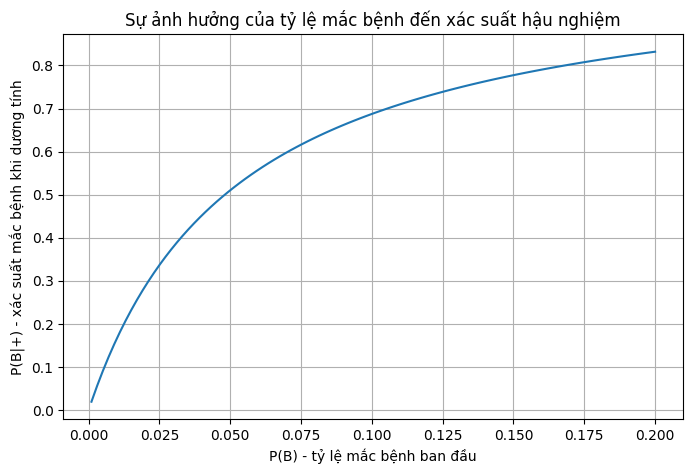

In [46]:
P_B_vals = np.linspace(0.001, 0.2, 100)

pos_vals = [] # danh sách rỗng để lưu các giá trị P(B∣+)

for P_B in P_B_vals:

    P_pos = (
        P_pos_givenB * P_B
        + P_pos_givenNB * (1-P_B)
    )

    P_B_given_pos = (
        P_pos_givenB * P_B
    ) / P_pos

    pos_vals.append(P_B_given_pos)

plt.figure(figsize=(8,5))

plt.plot(P_B_vals, pos_vals)

plt.xlabel("P(B) - tỷ lệ mắc bệnh ban đầu")
plt.ylabel("P(B|+) - xác suất mắc bệnh khi dương tính")
plt.title("Sự ảnh hưởng của tỷ lệ mắc bệnh đến xác suất hậu nghiệm")

plt.grid(True)
plt.show()

## Lý giải kết quả phản trực giác:

Bệnh hiếm nên số người khỏe mạnh rất lớn. Chỉ cần xuất hiện một tỉ lệ dương tính giả 0.05 cũng tạo ra rất nhiều dương tính giả (gọi chung là tỉ lệ nền quá nhỏ) => phần lớn trong tập dữ liệu người có kết quả dương tính, phần lớn lại là người không mắc bệnh.

## 3. Xây dựng một bộ lọc spam đơn giản theo Naive Bayes trên vài từ khóa cho sẵn; tính P(spam/email) cho 2-3 email ví dụ.

In [47]:
from collections import Counter # đếm số lần xuất hiện của từ
import re

# dữ liệu máy tui

tramyte_emails = [
    "lich thu bhyt dot 4 nam 2026",
    "thong bao thu bao hiem y te sinh vien",
    "nhac lai lich thu bhyt nam 2026"
]

duolingo_emails = [
    "ban da bo lo bai hoc hom nay",
    "hay quay lai de tiep tuc chuoi ngay hoc",
    "duolingo nhac nho hoc tieng anh hom nay"
]

# tìm tất cả các từ, tách từ và đưa về chữ thường, không in hoa
def tokenize(text):
    return re.findall(r'\w+', text.lower())

tramyte_words = []
for email in tramyte_emails:
    tramyte_words.extend(tokenize(email))

duolingo_words = []
for email in duolingo_emails:
    duolingo_words.extend(tokenize(email))

tramyte_counts = Counter(tramyte_words)
duolingo_counts = Counter(duolingo_words)

vocab = set(tramyte_words + duolingo_words)

# xác suất tiên nghiệm và chuẩn bị dữ liệu tính Naive Bayes

P_tramyte = len(tramyte_emails) / (
    len(tramyte_emails) + len(duolingo_emails)
)

P_duolingo = len(duolingo_emails) / (
    len(tramyte_emails) + len(duolingo_emails)
)

In [48]:
# Naive Bayes

def predict(email): # hàm này dự đoán email mới thuộc tập nào

    words = tokenize(email)

    for word in words:

        p_word_tramyte = (tramyte_counts[word] + 1
                          ) / (sum(tramyte_counts.values()) + len(vocab)
                               )
        p_word_duolingo = (duolingo_counts[word] + 1
                          ) / (sum(duolingo_counts.values()) + len(vocab)
                               )
        
        # nhân các xác suất
        P_tramyte *= p_word_tramyte 
        P_duolingo *= p_word_duolingo

    total = P_tramyte + P_duolingo

    # xác suất hậu nghiệm
    prob_tramyte = P_tramyte / total
    prob_duolingo = P_duolingo / total

    if prob_tramyte > prob_duolingo:
        label = "Email từ trạm y tế"
    else:
        label = "Email từ con quĩ Duolingo"

    return label, prob_tramyte, prob_duolingo

Email được tách thành các từ khóa riêng biệt và tính xác suất xuất hiện của chúng trong từng lớp. Các xác suất được nhân với xác suất tiên nghiệm của lớp để tạo điểm số. Cuối cùng chuẩn hóa thành xác suất hậu nghiệm và đẩy email đó vào lớp xác suất lớn hơn.